In [16]:
import sys, pathlib
import pandas as pd
# Add typing import to handle Optional type hint
from typing import Optional, List, Dict, Any  # Import typing module with commonly used types

proj_src = pathlib.Path().resolve().parent / "motec-ld-export-ui" / "motec-to-csv" / "src"
sys.path.append(str(proj_src))
from motec_converter import parse_race_data, to_pandas
sys.path.remove(str(proj_src))
import matplotlib.pyplot as plt
import numpy as np

In [17]:
dyno_df = pd.read_csv("dyno.csv", index_col=0, parse_dates=True)
dyno_df

C:\Users\kafle\AppData\Local\Temp\ipykernel_15324\1703723925.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dyno_df = pd.read_csv("dyno.csv", index_col=0, parse_dates=True)


,Graph Time (sec),Tailshaft Speed (rpm),Power (kW),Speed (km/h),OnTime L (%),Tq L (Nm),Axle Tq R (Nm),Speed L (rpm),Speed R (rpm),OnTime R (%),Axle Torque (Nm),Axle Speed (rpm),Comments,TqC (Nm),Time (sec),Motor Speed (rpm),Motor Torque (Nm)
Run Name,,,,,,,,,,,,,,,,,
MUREV2025.0002,9.75,18.6,0.000,0.242,0.0,0.0,4.2,0.0,9.5,0.0,4.2,4.752,NaN,NaN,NaN,18.576000,1.074419
MUREV2025.0002,9.80,93.8,0.004,1.384,1.1,0.0,5.1,0.0,48.0,2.9,5.1,23.984,NaN,NaN,NaN,93.755636,1.304651
MUREV2025.0002,9.85,97.8,0.010,2.203,5.8,0.0,5.6,0.0,50.0,15.9,5.6,25.024,NaN,NaN,NaN,97.821091,1.432558
MUREV2025.0002,9.90,100.4,0.017,2.778,7.7,0.0,6.1,0.0,51.3,21.1,6.1,25.672,NaN,NaN,NaN,100.354182,1.560465
MUREV2025.0002,9.95,101.5,0.023,3.175,7.6,0.0,6.6,0.0,51.9,20.0,6.6,25.968,NaN,NaN,NaN,101.511273,1.688372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MUREV2025.0015,NaN,5174.1,41.863,101.084,NaN,NaN,NaN,NaN,NaN,NaN,308.0,1323.304,NaN,92.937,36.90,5172.915636,78.790698
MUREV2025.0015,NaN,5176.8,41.845,101.163,NaN,NaN,NaN,NaN,NaN,NaN,307.9,1323.992,NaN,92.825,36.95,5175.605091,78.765116
MUREV2025.0019,NaN,1963.4,19.683,38.462,NaN,NaN,NaN,NaN,NaN,NaN,380.5,502.160,NaN,114.841,1.30,1962.989091,97.337209


can't find 3
can't find 4
can't find 5
can't find 6
can't find 7
can't find 11
can't find 12
can't find 13
can't find 14
can't find 16
can't find 17
can't find 18
[2, 8, 9, 10, 15, 19]


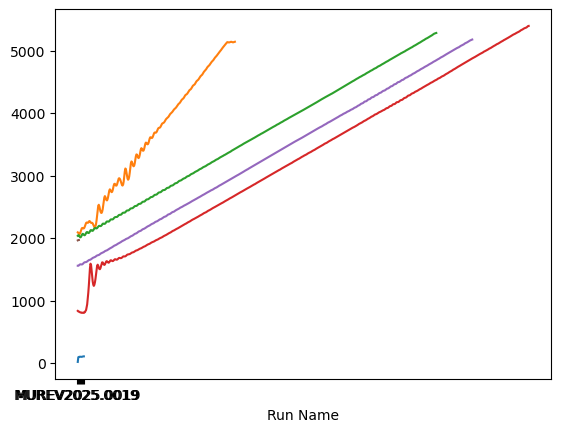

In [18]:
working = []
for i in range(2,20):
    try:
        temp_dyno_df = dyno_df.loc[f"MUREV2025.{i:04d}"].copy()
        temp_dyno_df.loc[f"MUREV2025.{i:04d}"]["Motor Speed (rpm)"].plot()
        working.append(i)
    except:
        print(f"can't find {i}")
print(working)

In [19]:
def find_and_plot_efficiency(cur_dyno_df, motec_trim):
    cur_dyno_df["omega"] = 2 * np.pi * cur_dyno_df["Motor Speed (rpm)"] / 60
    cur_dyno_df["P_out"] = cur_dyno_df["Motor Torque (Nm)"] * cur_dyno_df["omega"] / 1000  # kW
    
    motec_trim["Car.Data.Inverter.InverterDCCurrent"] = motec_trim["Car.Data.Inverter.InverterDCCurrent"]/10
    motec_trim["Car.Data.Inverter.InverterDCVoltage"] =(motec_trim["Car.Data.Inverter.InverterDCVoltage"])/10
    motec_trim["P_in"] = motec_trim["Car.Data.Battery.BatteryPower"] / 100000



    # Create the figure with 2 rows, 1 column
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 15))

    cur_dyno_df['P_out'].plot(ax=ax2, label='Power Out (Dyno)', color='blue')
    motec_trim['P_in'].plot(ax=ax1, label='Power In (Motec)', color='blue')
    ax1.set_title("Power Input ")
    ax1.set_ylabel("Power (kW)")
    ax2.set_title("Power Output ")
    ax2.set_ylabel("Power (kW)")


    cur_dyno_df["rpm_bin"] = (cur_dyno_df["Motor Speed (rpm)"] // 100) * 100
    cur_dyno_df = cur_dyno_df[cur_dyno_df["rpm_bin"] > 1800].copy()
    
    motec_trim["rpm_bin"] = (motec_trim["Car.Data.Motor.MotorRPM"] // 100) * 100
    motec_trim = motec_trim[motec_trim["rpm_bin"] > 1800].copy()
    
    merged = cur_dyno_df.merge(motec_trim, on="rpm_bin", how="inner")
    
    merged["eff"] = merged['P_out'] / merged["P_in"]
    
    eff_df = merged.groupby("rpm_bin")["eff"].mean()

    eff_df = eff_df.sort_index()
    
    ax3.plot(eff_df.index, eff_df, color='green')
    ax3.set_title("Motor Efficiency vs RPM")
    ax3.set_xlabel("RPM")
    ax3.set_ylabel("Efficiency")
    ax3.grid(True)
    plt.grid()
    plt.show()

# 1. (MUREV2025.0008 + speed_ramp_40-100_ramprate45_pl150.ld)

2062.2174545454545 5140.079272727273


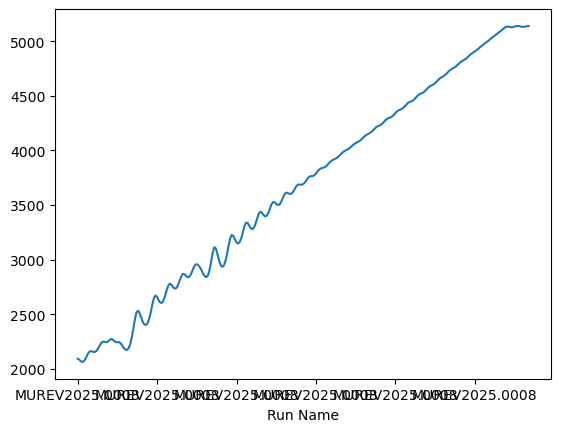

In [21]:
cur_dyno_df = dyno_df.loc["MUREV2025.0008"].copy()
cur_dyno_df.loc["MUREV2025.0008"]["Motor Speed (rpm)"].plot()
rpm_min = cur_dyno_df["Motor Speed (rpm)"].min()
rpm_max = cur_dyno_df["Motor Speed (rpm)"].max()
working.remove(8)

print(rpm_min, rpm_max)


<Axes: xlabel='Time'>

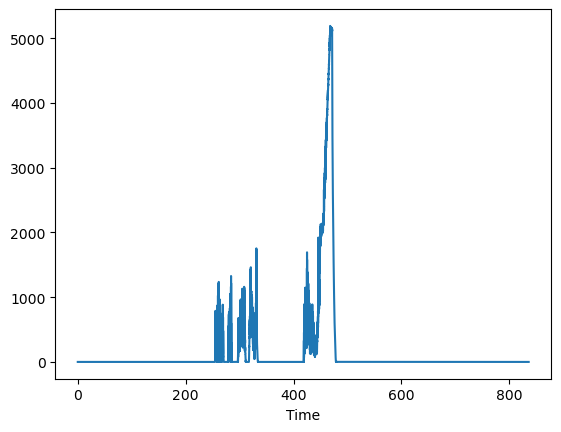

In [22]:
race_data = parse_race_data("speed_ramp_40-100_ramprate45_pl150.ld")
segments = to_pandas(race_data)

df = pd.concat(segments)
df["Car.Data.Motor.MotorRPM"].plot()


<Axes: xlabel='Time'>

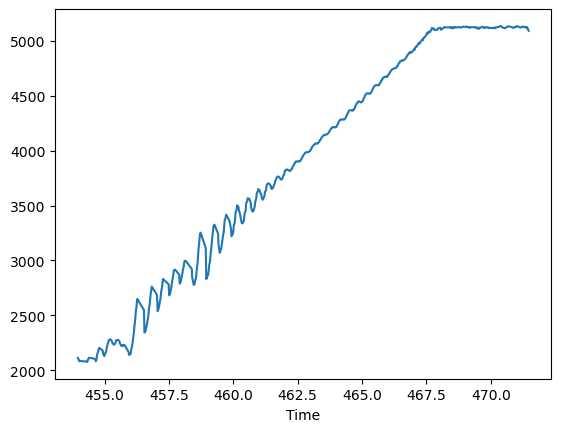

In [23]:
motec_trim = df[
    (df["Car.Data.Motor.MotorRPM"] >= rpm_min) &
    (df["Car.Data.Motor.MotorRPM"] <= rpm_max) &
    (df.index >= 453.6)
].copy()

motec_trim = motec_trim[
    motec_trim["Car.Data.Motor.MotorRPM"].diff() > 0
]

# Smoothing if needed
motec_trim = motec_trim.rolling(3).mean()

motec_trim["Car.Data.Motor.MotorRPM"].plot()

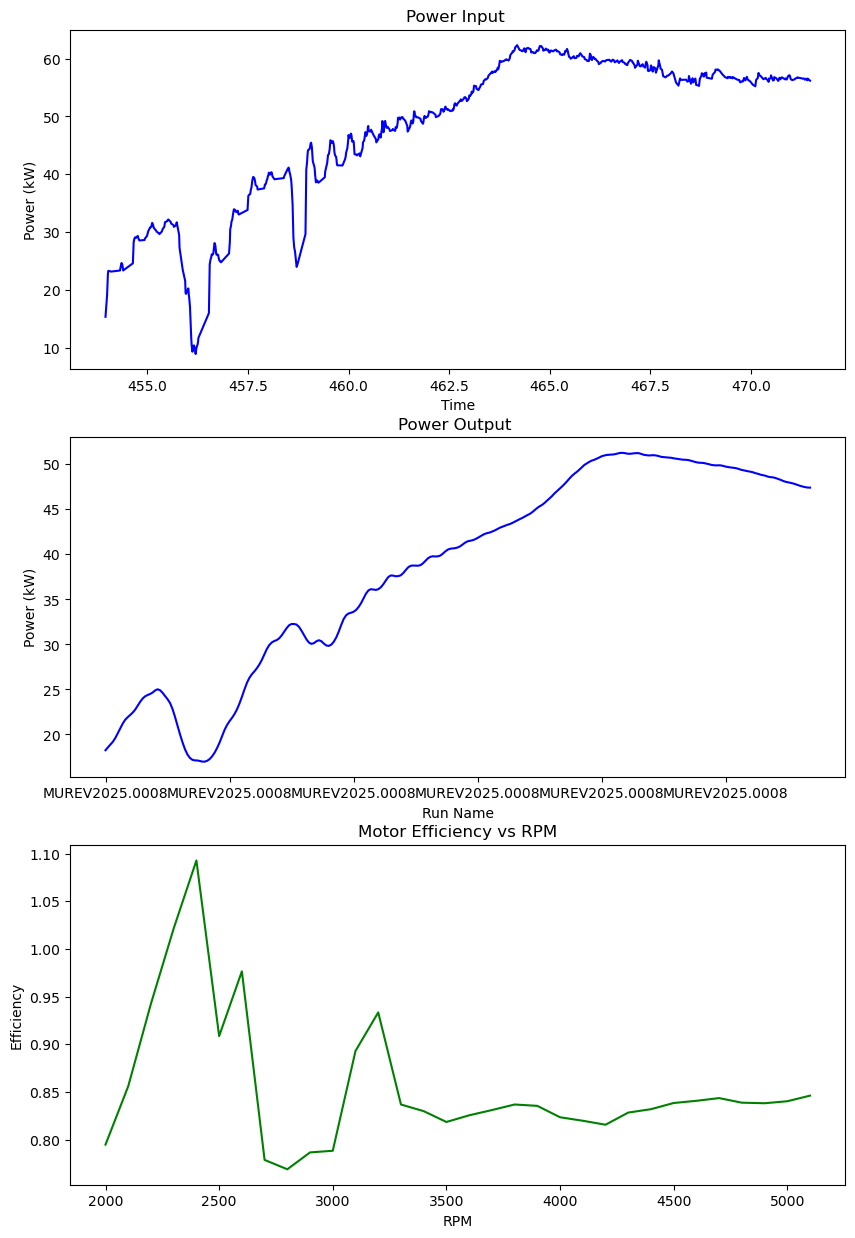

In [24]:
find_and_plot_efficiency(cur_dyno_df, motec_trim)

# 2. (MUREV2025.0010 + speedramp_run2.ld)

<Axes: xlabel='Time'>

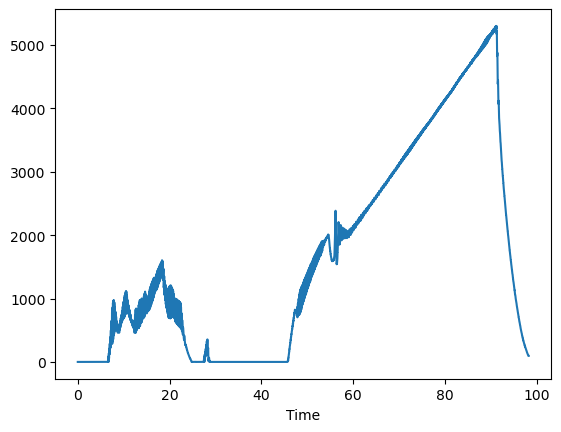

In [26]:
race_data = parse_race_data("speedramp_run2.ld")
segments = to_pandas(race_data)

df = pd.concat(segments)
df["Car.Data.Motor.MotorRPM"].plot()

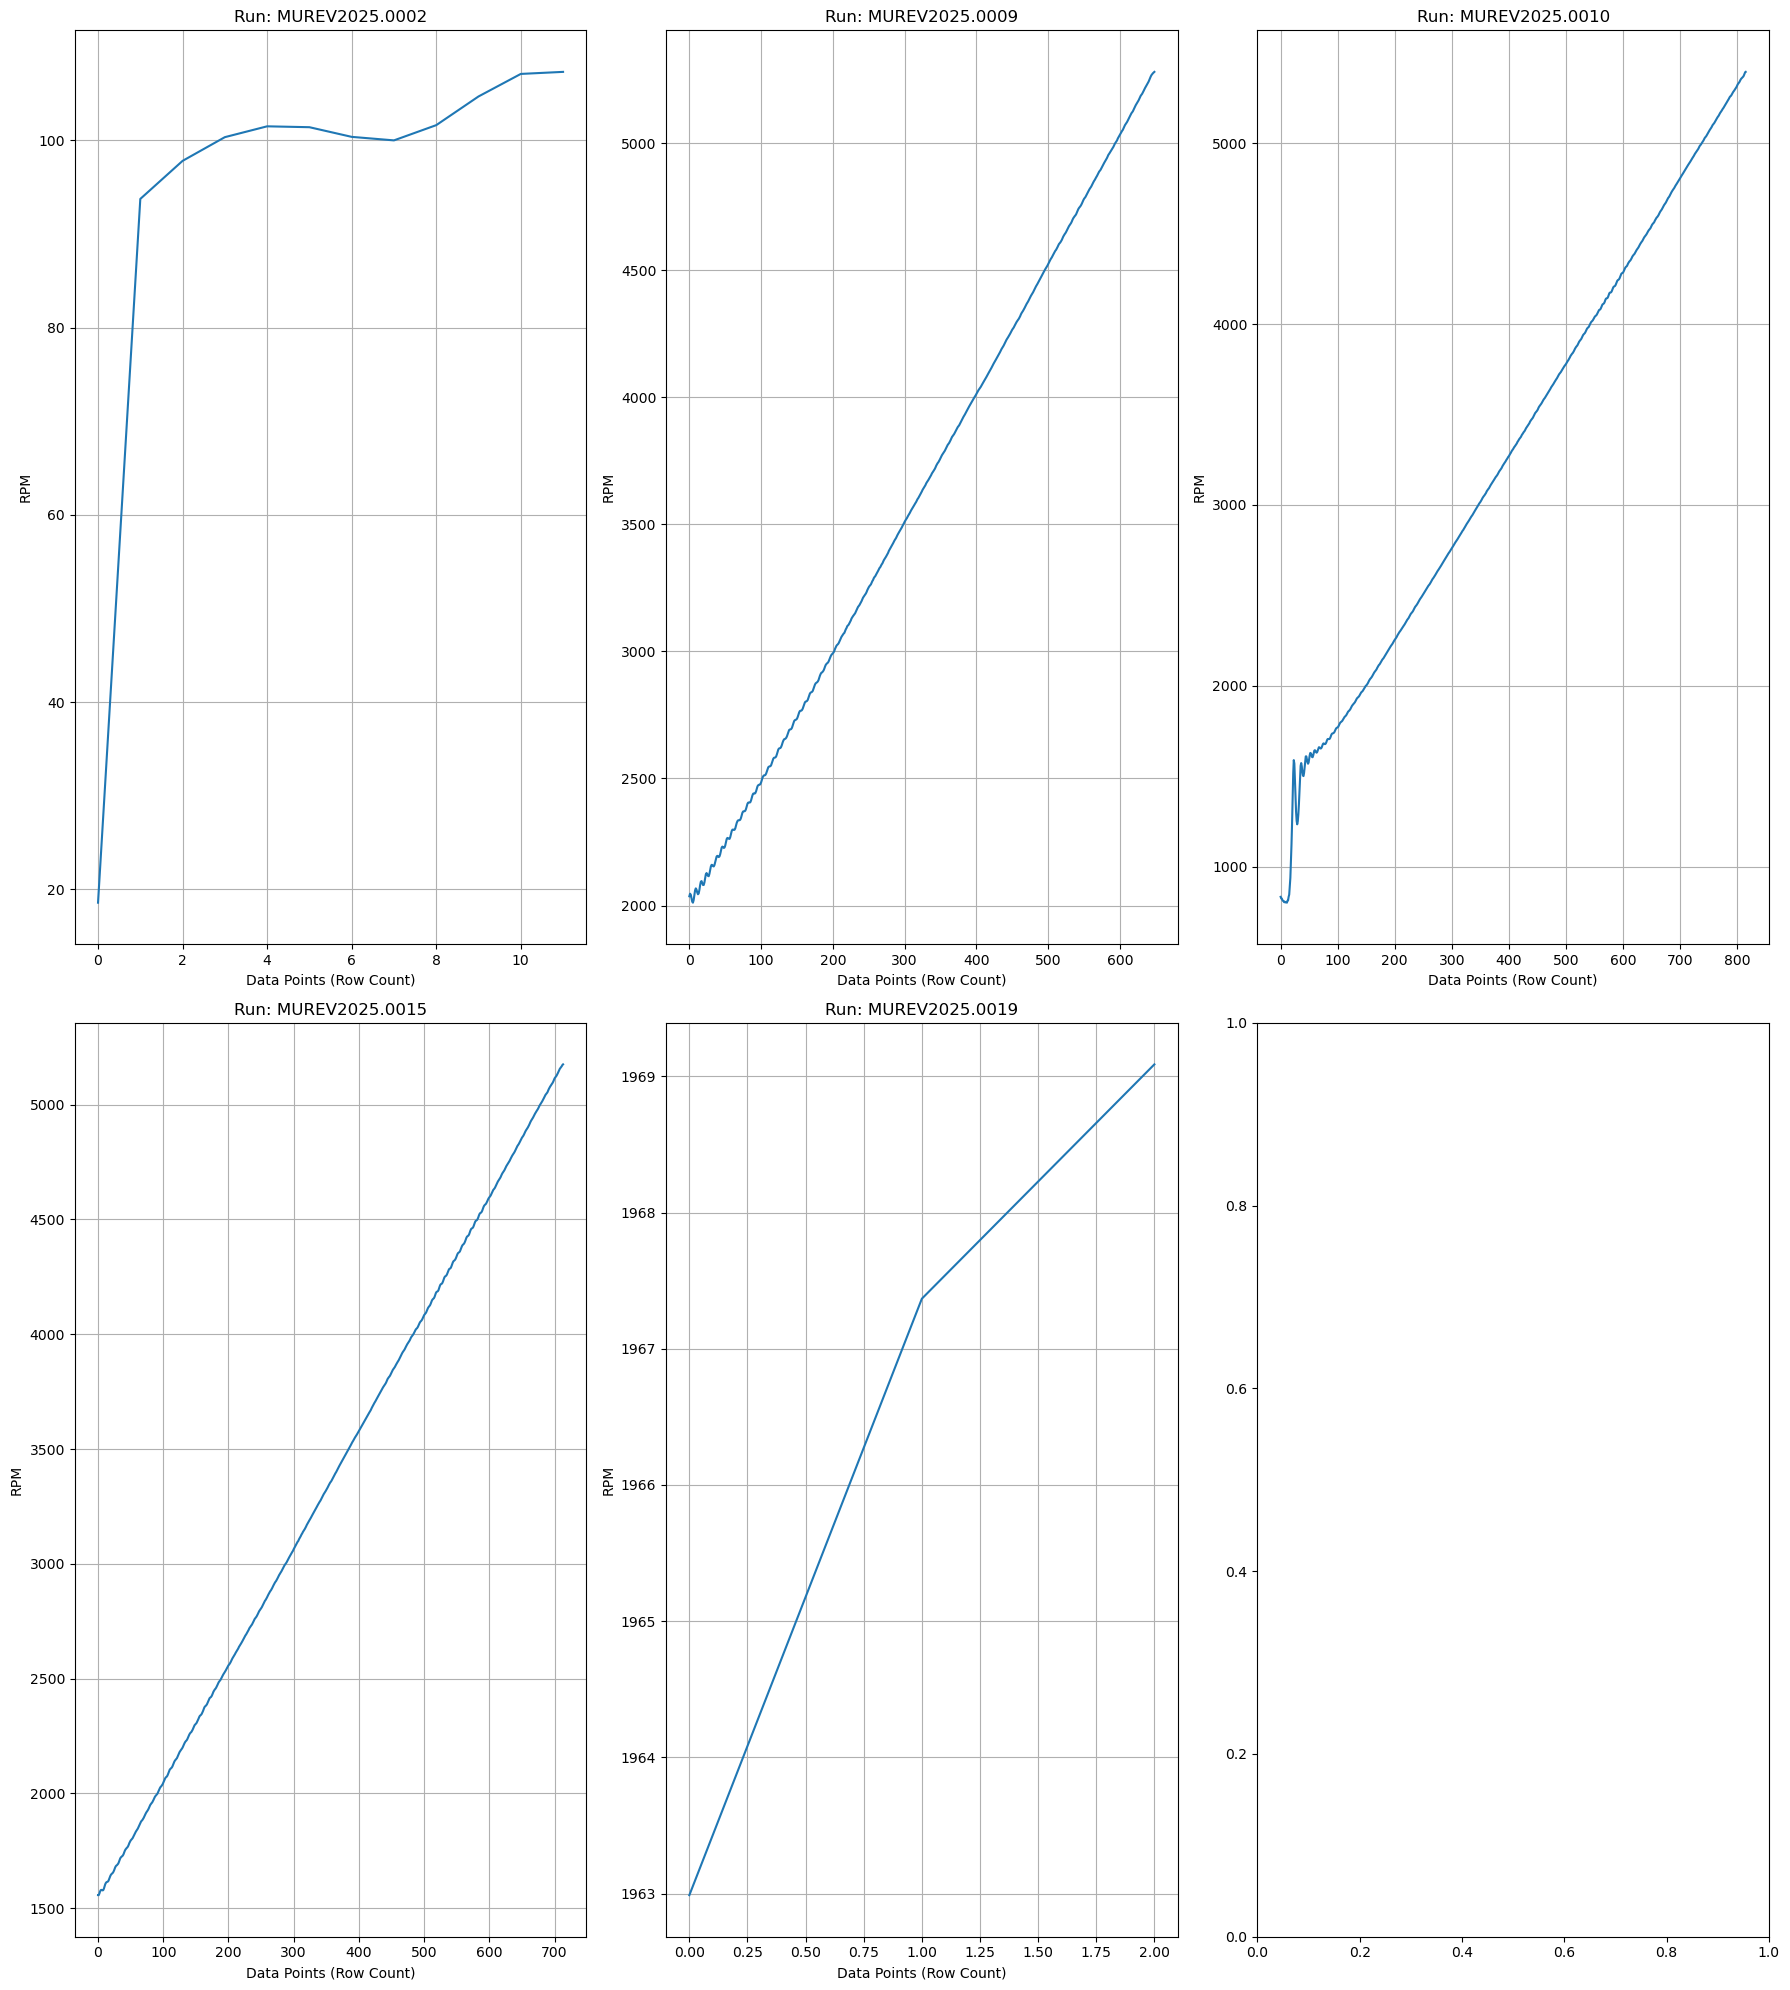

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(18, 20))
axes = axes.flatten()

for j,i in enumerate(working):
    label = f"MUREV2025.{i:04d}"
    ax = axes[j]
    
    try:
        # 1. Get the data for this run
        # 2. .reset_index() turns the row count into the new x-axis
        temp_df = dyno_df.loc[[label]].reset_index()
        
        # Plot without specifying 'x' uses the new numeric index
        temp_df["Motor Speed (rpm)"].plot(
            ax=ax, 
            title=f"Run: {label}",
            grid=True
        )
        ax.set_xlabel("Data Points (Row Count)")
        ax.set_ylabel("RPM")
        
    except KeyError:
        ax.set_visible(False)


plt.tight_layout()
plt.show()
# Select run 10

802.3018181818182 5393.294545454546


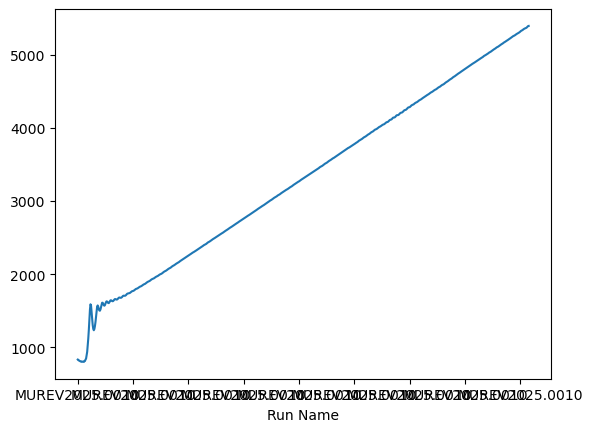

In [28]:
cur_ten_dyno_df = dyno_df.loc["MUREV2025.0010"].copy()
cur_ten_dyno_df.loc["MUREV2025.0010"]["Motor Speed (rpm)"].plot()
rpm_min = cur_ten_dyno_df["Motor Speed (rpm)"].min()
rpm_max = cur_ten_dyno_df["Motor Speed (rpm)"].max()
working.remove(10)

print(rpm_min, rpm_max)

<Axes: xlabel='Time'>

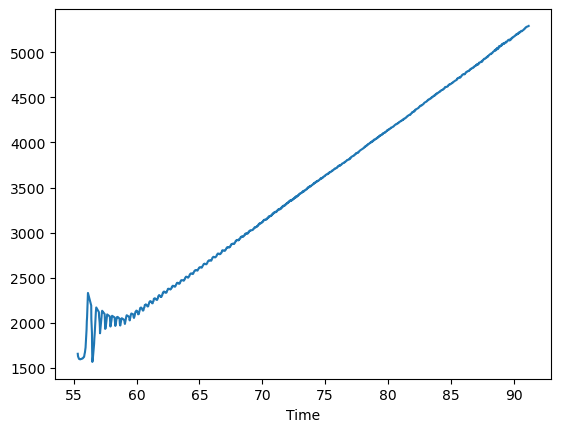

In [29]:
motec_ten_trim = df[
    (df["Car.Data.Motor.MotorRPM"] >= rpm_min) &
    (df["Car.Data.Motor.MotorRPM"] <= rpm_max) &
    (df.index >= 54.6) &
    (df.index <= 91.2)
].copy()

motec_ten_trim = motec_ten_trim[
    motec_ten_trim["Car.Data.Motor.MotorRPM"].diff() > 0
]

# Smoothing if needed
motec_ten_trim = motec_ten_trim.rolling(5).mean()

motec_ten_trim["Car.Data.Motor.MotorRPM"].plot()

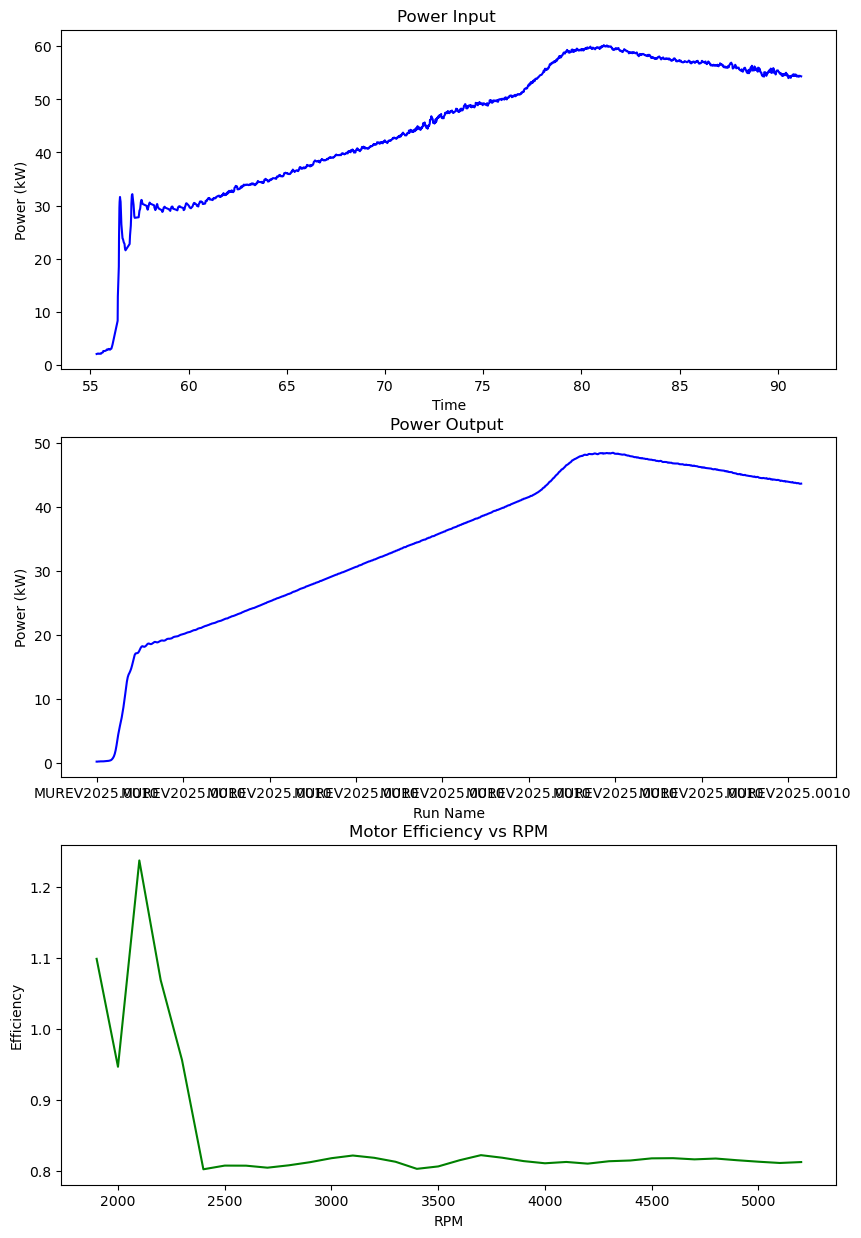

In [30]:
find_and_plot_efficiency(cur_ten_dyno_df,motec_ten_trim)

# 3. I think the data below here maybe useless look below for explanation

C:\Users\kafle\AppData\Local\Temp\ipykernel_15324\2691408300.py:5: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  df[250:]["Car.Data.Motor.MotorRPM"].plot()


<Axes: xlabel='Time'>

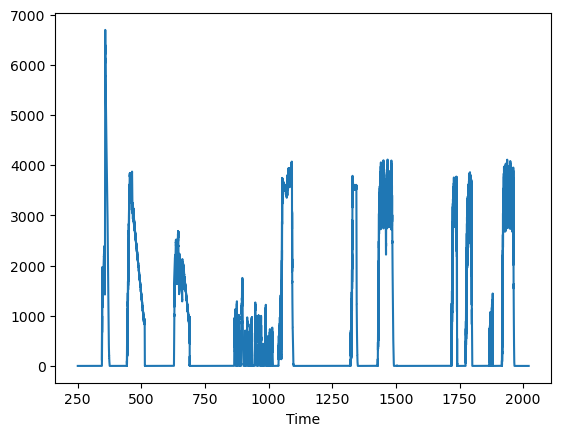

In [32]:
race_data = parse_race_data("S1_#10889_20260313_153131.ld")
segments = to_pandas(race_data)

df = pd.concat(segments)
df[250:]["Car.Data.Motor.MotorRPM"].plot()

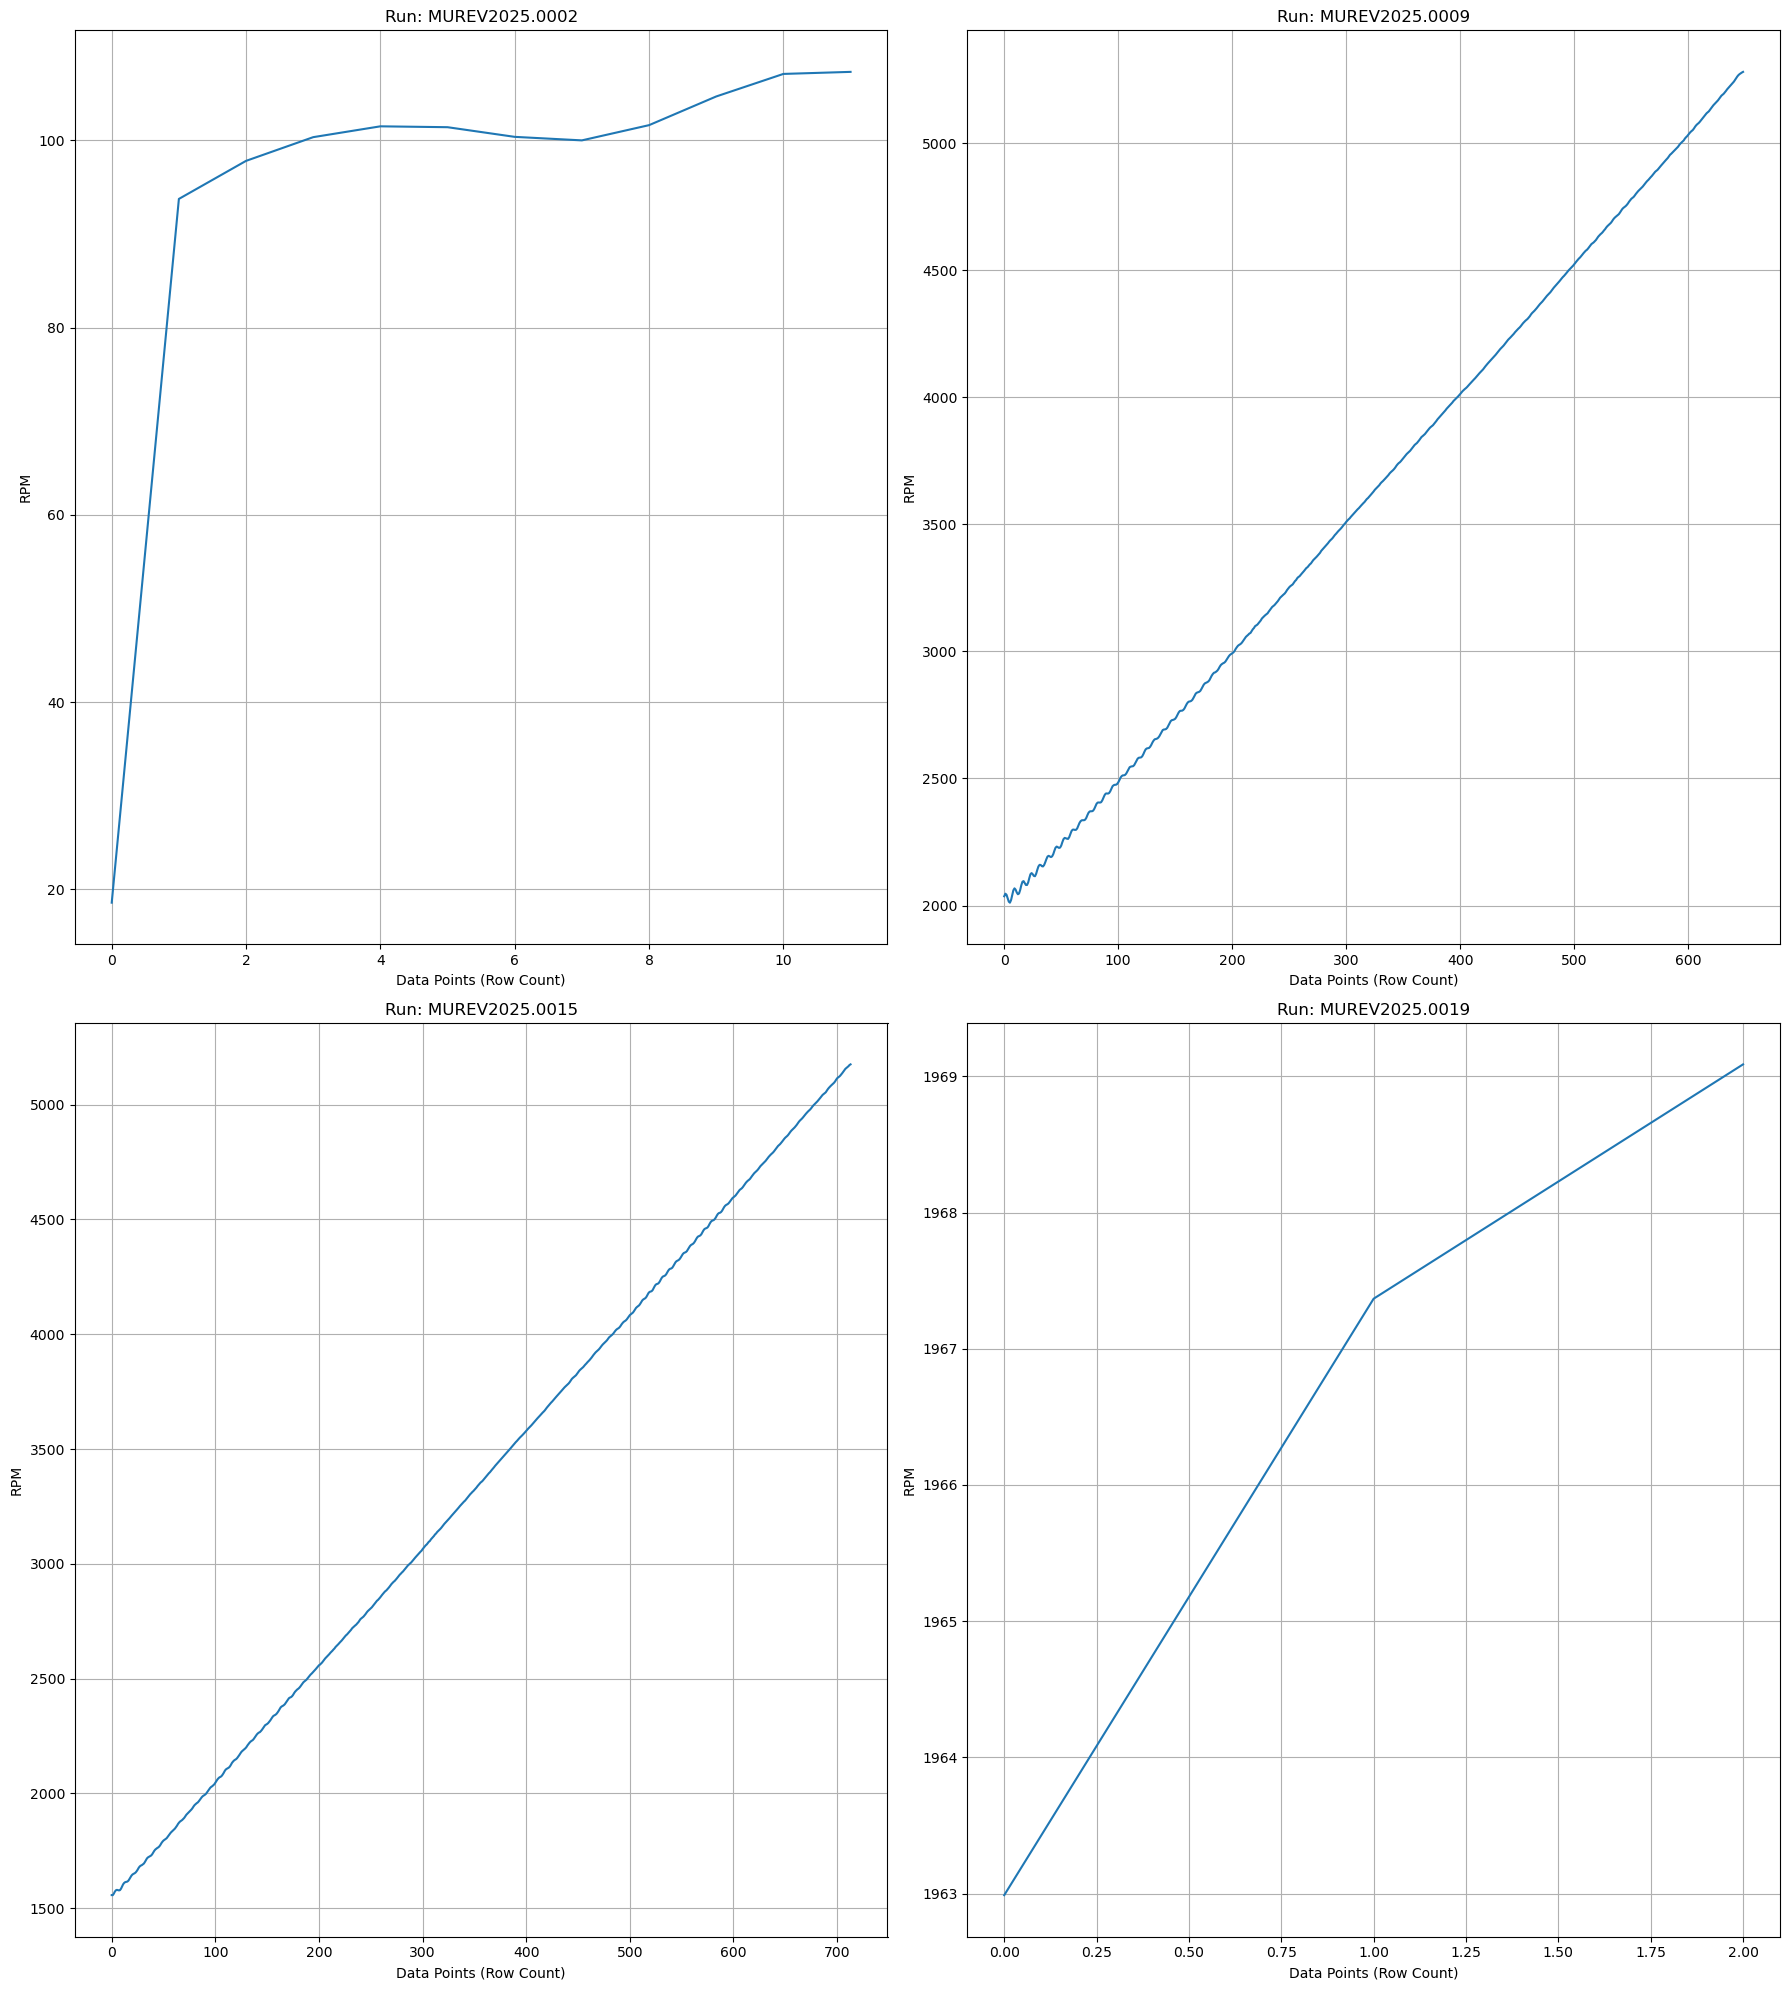

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(18, 20))
axes = axes.flatten()

for j,i in enumerate(working):
    label = f"MUREV2025.{i:04d}"
    ax = axes[j] # This will always be between 0 and 17
    
    try:
        # 1. Get the data for this run
        # 2. .reset_index() turns the row count into the new x-axis
        temp_df = dyno_df.loc[[label]].reset_index()
        
        # Plot without specifying 'x' uses the new numeric index
        temp_df["Motor Speed (rpm)"].plot(
            ax=ax, 
            title=f"Run: {label}",
            grid=True
        )
        ax.set_xlabel("Data Points (Row Count)")
        ax.set_ylabel("RPM")
        
    except KeyError:
        ax.set_visible(False)


plt.tight_layout()
plt.show()

# Explanation
If you look at the above graphs they are all basically straight lines with no difference in acceleration so could be mapped to basically any run, plus if you look at the x axis it tells you the row number in that data set so the run MUREV2025.0002 only has around 11 data points and MUREV2025.0019 only has 2 data points so basically no data to generate insights, MUREV2025.0015 does have a lot of points so could be usefull to look into RPM binning which we were doing initially but again, no specific motec dataset to match to so any result could just be as a result of noise/ no meaningful relationship

In [35]:
all_dfs = []

base_dir = pathlib.Path()
ld_files = sorted(base_dir.glob("*.ld"))
#ld_files = ["S1_#10889_20260313_144534.ld"]


for f in ld_files:
    print(f)
    race_data = parse_race_data(str(f))
    segments = to_pandas(race_data)
    
    df = pd.concat(segments)
    all_dfs.append(df)

# 4. Concatenate everything at once and sort by the index (usually timestamp)
motec_df = pd.concat(all_dfs).sort_index()

"""
name = "S1_#10889_20260313_140852.ld"
race_data = parse_race_data(name)
segments = to_pandas(race_data)
motec_df = pd.concat(segments).sort_index()

ld_files = sorted(base_dir.glob("*.ld"))
for f in ld_files:
    race_data = parse_race_data(str(f))
    segments = to_pandas(race_data)
    df = pd.concat(segments)

race_data = parse_race_data(name)
segments = to_pandas(race_data)
motec_df = pd.concat(segments).sort_index()
"""
(motec_df["Car.Data.Battery.BatteryPower"]/1000).describe()


initial testing.ld
S1_#10889_20260313_140852.ld
S1_#10889_20260313_144534.ld
S1_#10889_20260313_153131.ld
speed_ramp_40-100_ramprate45_pl150.ld
speedramp_run2.ld


count    553691.000000
mean        279.067243
std         971.025224
min       -3497.054000
25%           0.000000
50%           0.000000
75%           4.281000
max        6296.340000
Name: Car.Data.Battery.BatteryPower, dtype: float64